In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf
import numpy as np
import jax

print(jax.devices())

- Proper defaults for all priors
- Discuss best practice for defaults
    + e.g. plotting
    + what about default and then check if none and set default


- Context
- Augmentation

## Specify Prior

In [5]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(-1.0, 1.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=sup.prior.Prior(dist="halfnormal", scale=0.02),
            initial_prior=sup.prior.Prior(dist="normal", low=0.0, high=1.0)
        ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.AutoRegression(),
            sup.transition.Jump()
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[15.0, 1.5]),
        bounds=(0.0, 4.0)
    ),
    bias = 0.5,
    tau = sup.prior.Prior(dist="halfnormal", scale=0.15)
)

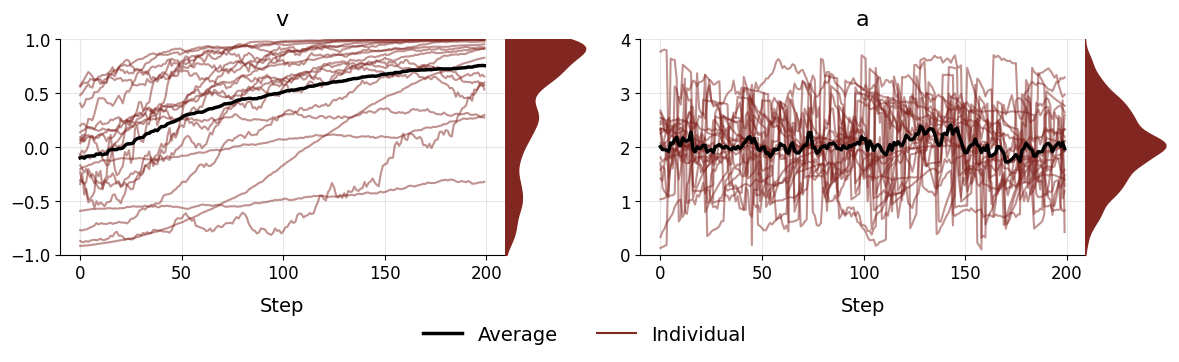

In [7]:
p = joint_prior.plot_time_varying_prior()

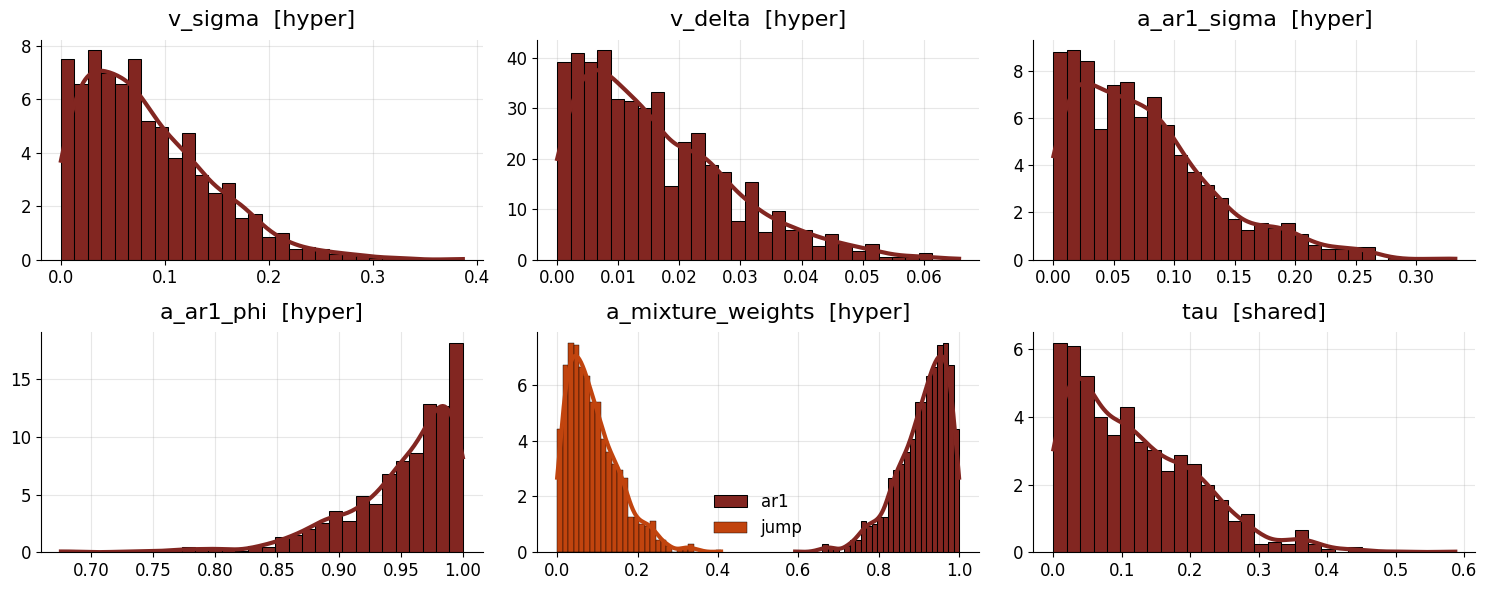

In [8]:
p = joint_prior.plot_time_invariant_prior(num_cols=3)

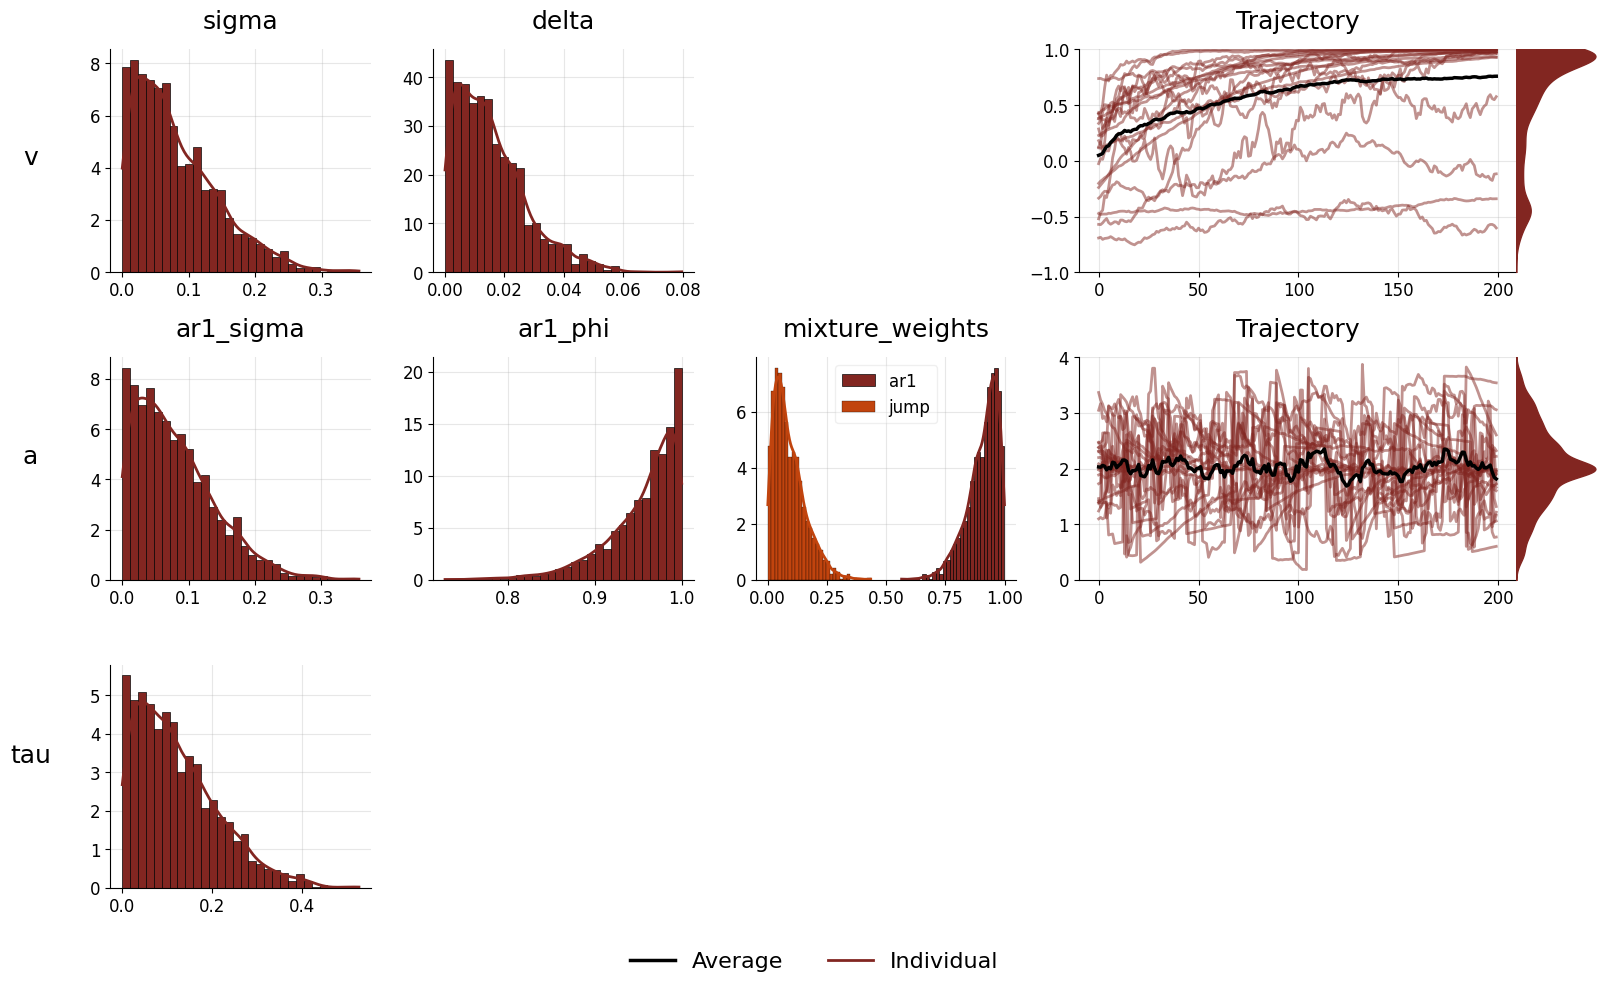

In [9]:
p = joint_prior.plot_joint_prior()

## Specify Generative Model

In [10]:
ddm = sup.simulation.sample_ddm

In [11]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

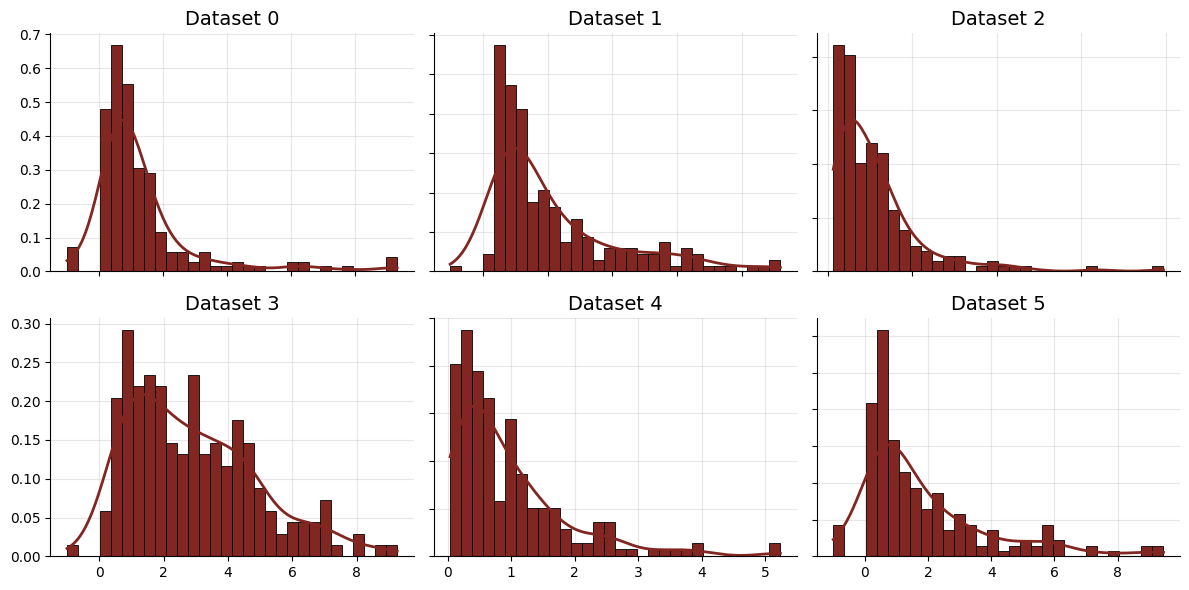

In [15]:
# 6 individual trajectories for data dim 0, with marginal distribution
plot = generative_model.plot_push_forward(
    num_sim=6,
    num_steps=200,
    data_dim=0,
    kind="dist"
)


## Specify Workflow

- Data simulation should be outside
- Allow for kwargs
- Augmentation missing process, most simple just add randomly -1
- Missing augmentation class, with flexivblity and good defaults

In [16]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="new_v3",
)

Existing checkpoints are not automatically loaded. Upon refitting, the checkpoints will be overwritten.
To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model("new_v3/model.keras")


### Offline Training

In [17]:
train_data = workflow.simulator.sample(
    batch_size=1000,
    num_steps=100,
    tile_to_steps=True
)
test_data = workflow.simulator.sample(
    batch_size=200,
    num_steps=100,
    tile_to_steps=True
)

In [18]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=test_data,
    epochs=2,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - loss: -0.4686 - val_loss: -1.0793
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: -1.1816 - val_loss: -1.3374


INFO:bayesflow:Training completed in 14.49 seconds.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'new_v3/model.keras'.
To load it, use approximator = keras.saving.load_model("new_v3/model.keras").


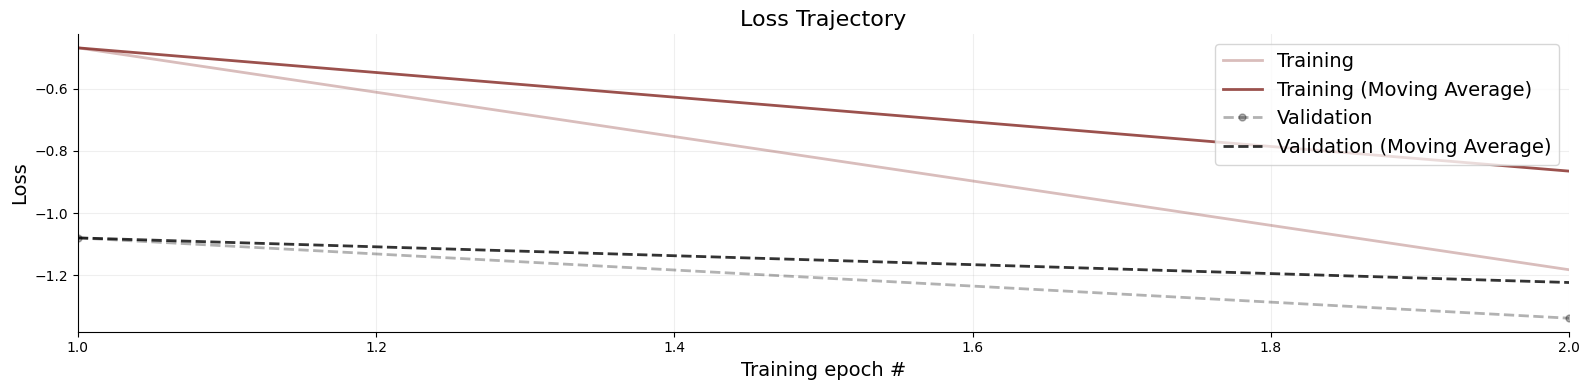

In [19]:
plot = workflow.plot_history(history)

## Online Training

In [21]:
history = workflow.fit_online(
    num_steps=100,
    epochs=5,
    num_batches_per_epoch=50,
    batch_size=16
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: -1.5229
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: -1.8097
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: -2.0130
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: -2.2049
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: -2.2662


INFO:bayesflow:Training completed in 16.21 seconds.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'new_v3/model.keras'.
To load it, use approximator = keras.saving.load_model("new_v3/model.keras").


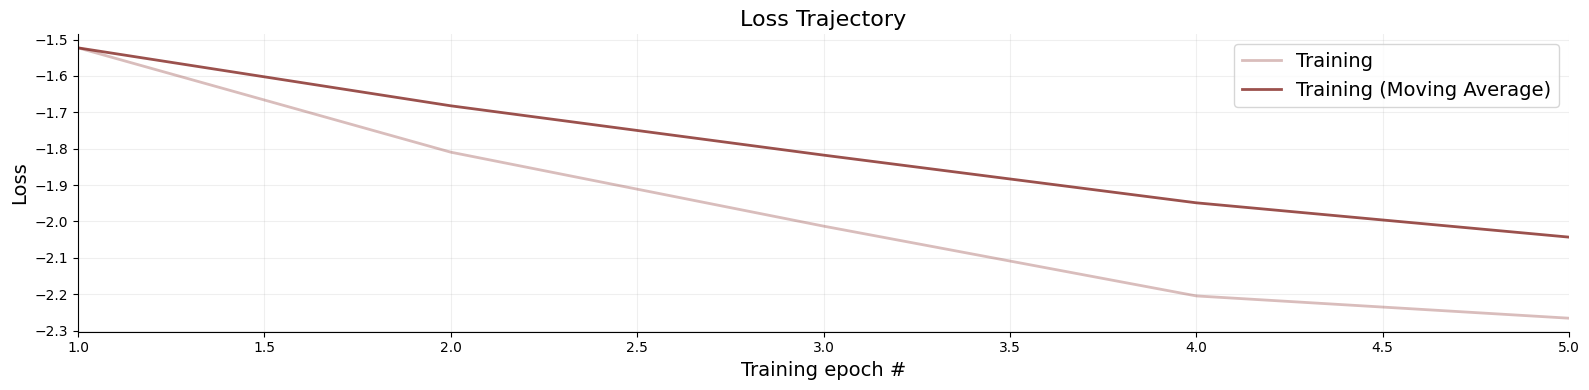

In [22]:
plot = workflow.plot_history(history)

## Validation

In [23]:
val_data = workflow.simulator.sample(
    batch_size=100,
    num_steps=100
)

In [24]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=50,
    
)

Summarizing:   0%|          | 0/20 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/20 [00:00<?, ?batch/s]

### Time-varying Parameters

/Users/lschumacher/Documents/GitHub/superstats/examples/../superstats/diagnostics/plots/time_varying_validation.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


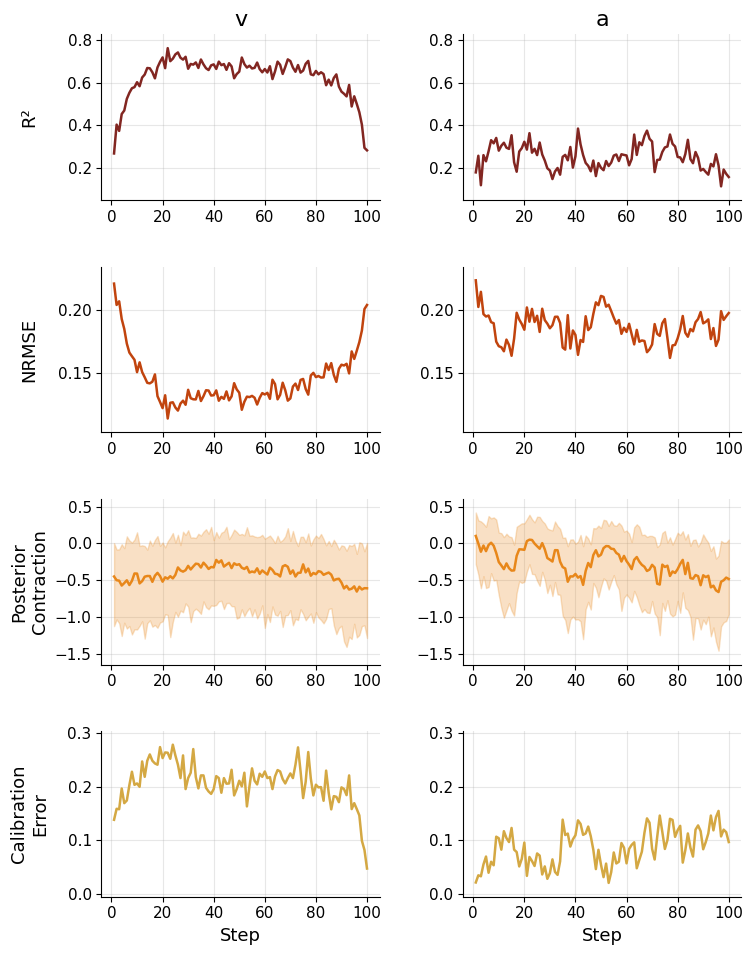

In [25]:
fig = workflow.validate_time_varying(val_data, samples)

### Time-invariant Parameters

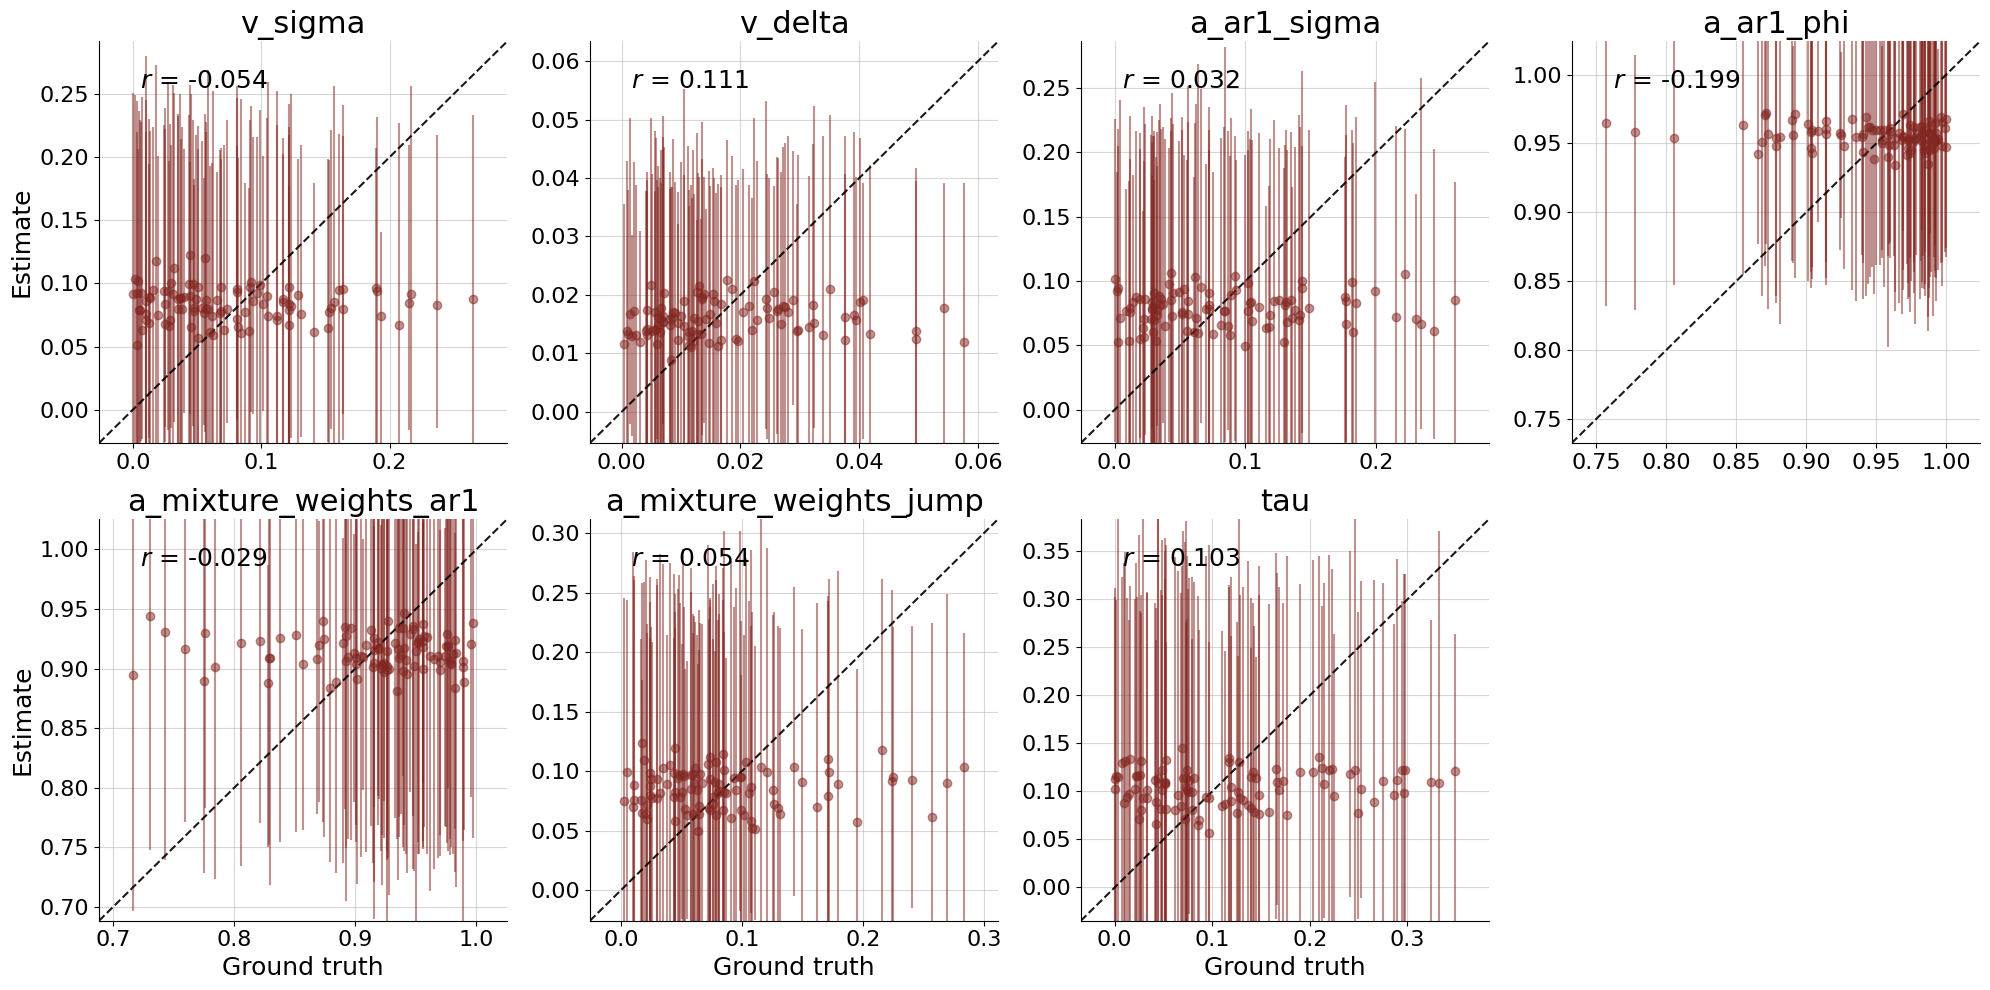

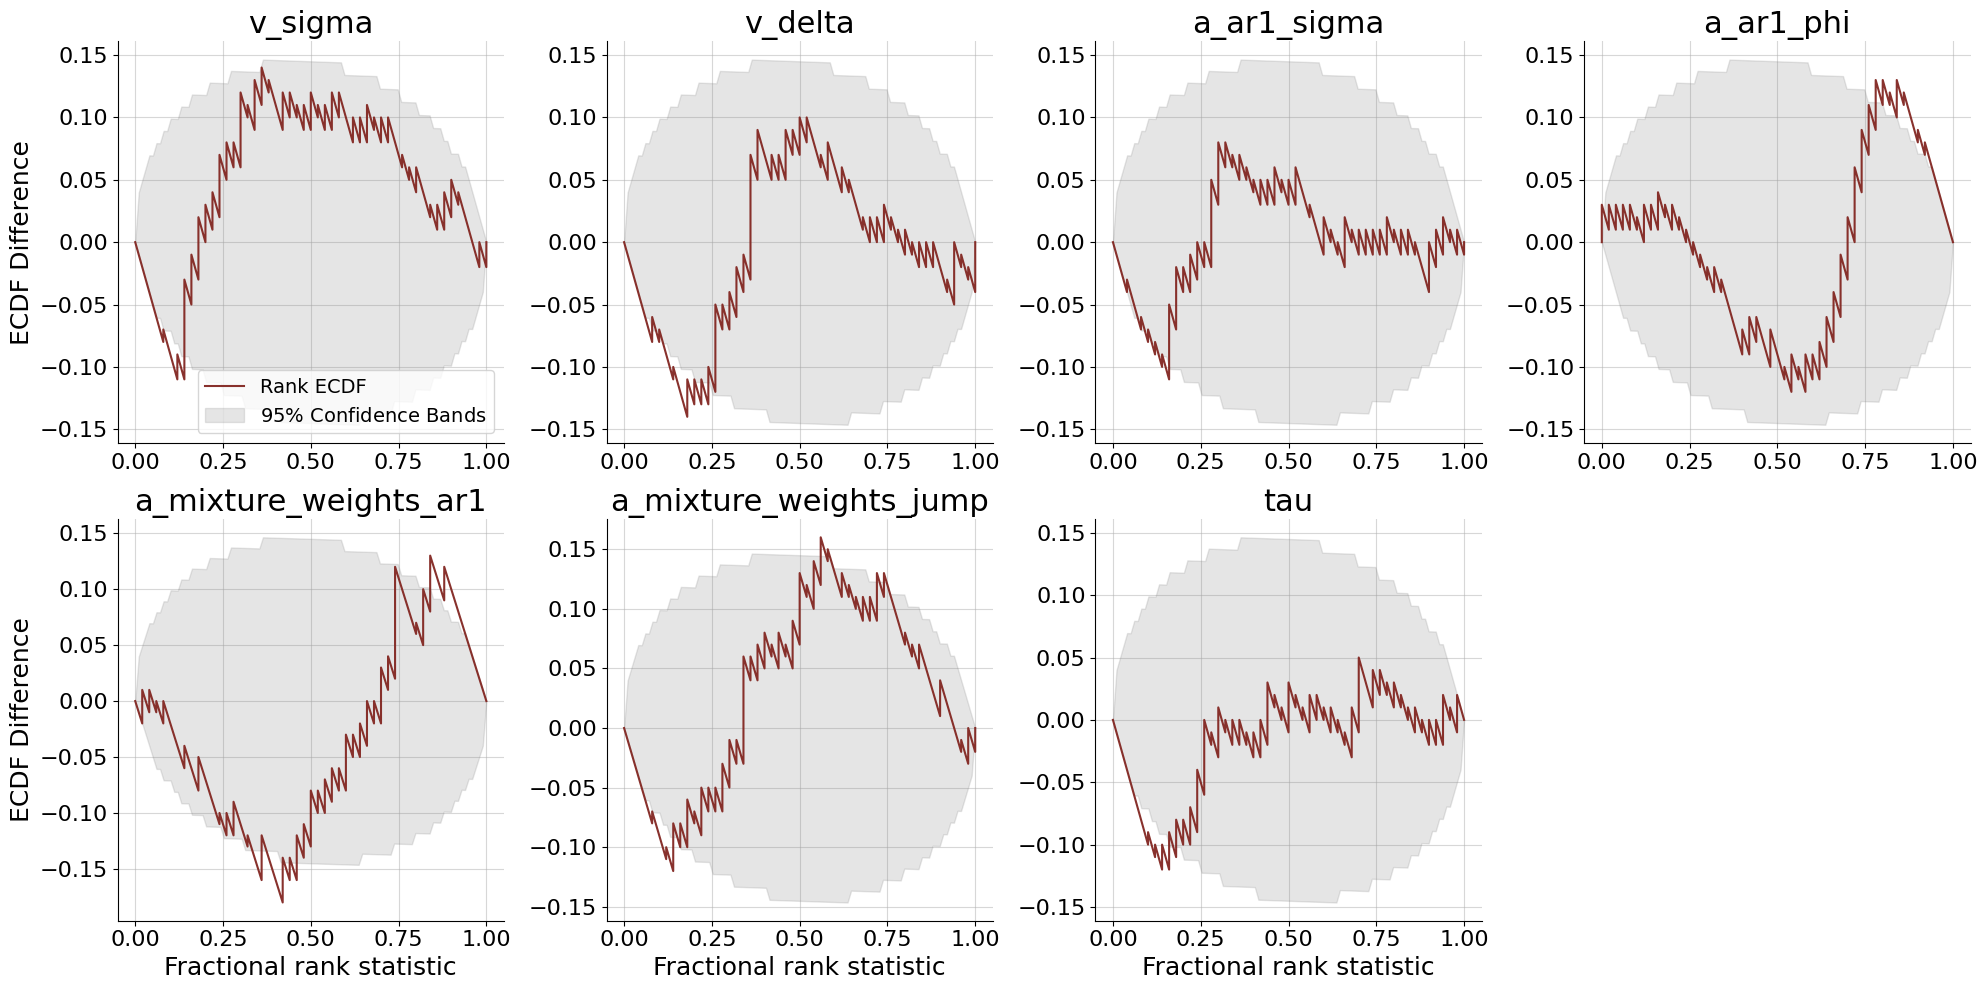

In [37]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    val_data,
    samples
)

## Data Fitting

In [38]:
data = workflow.simulator.sample(5, 100)

In [ ]:
samples = workflow.sample(data['data'])

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

In [67]:
samples['v'].shape

(5, 1000, 100, 1)

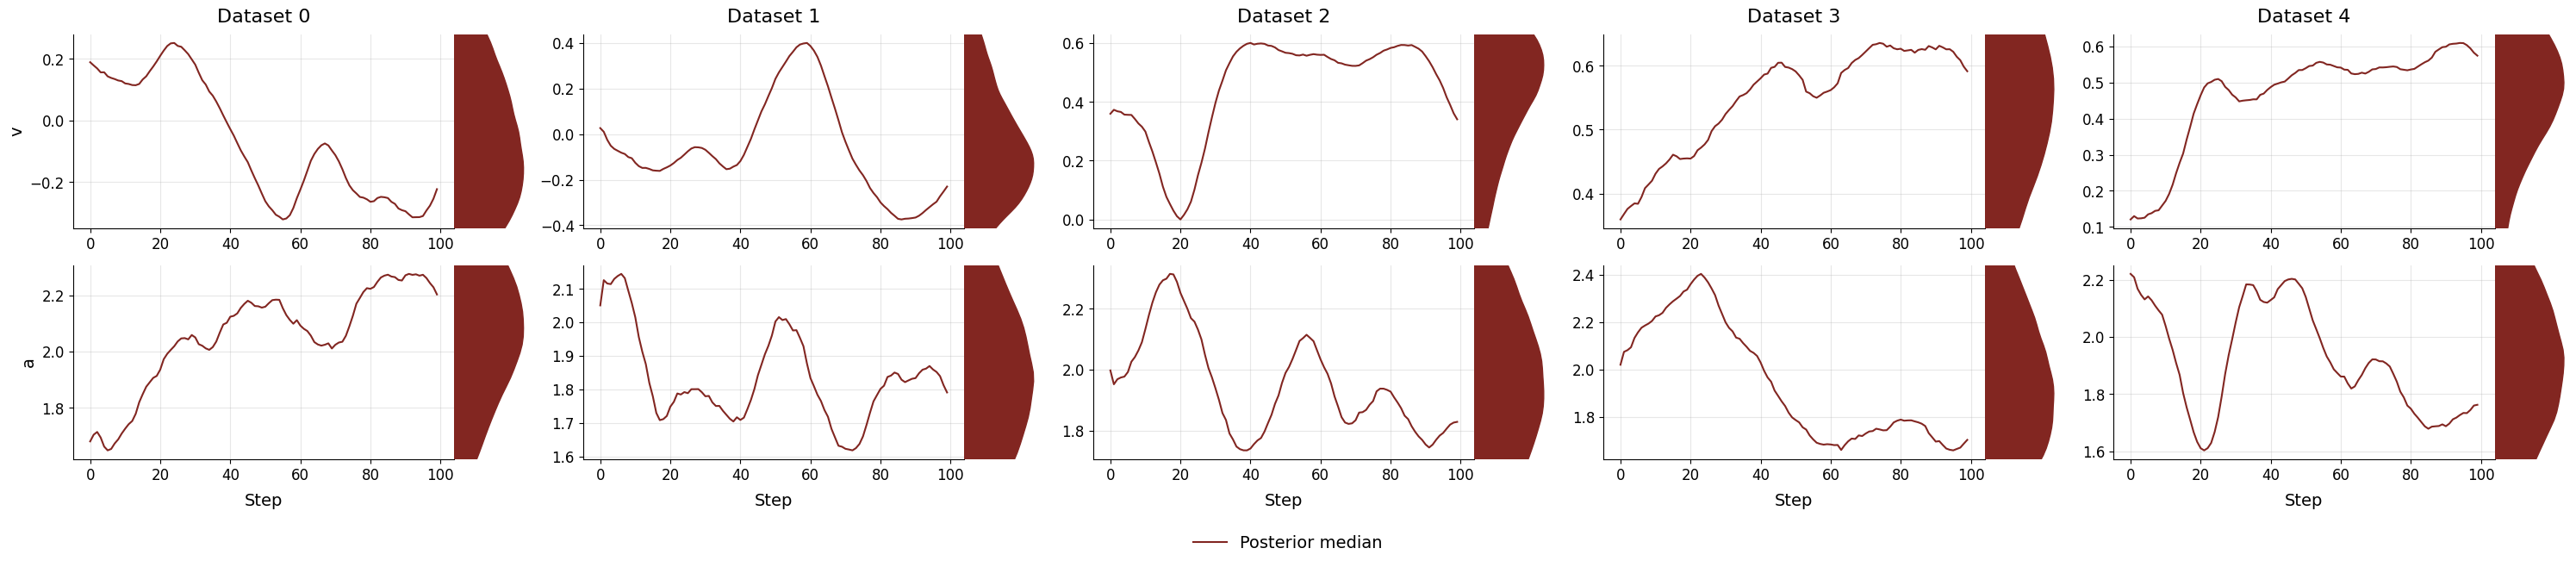

In [74]:
local_keys = workflow.simulator.local_keys

fig = sup.diagnostics.plots.plot_time_varying_posterior(
    samples,
    local_keys,
    aggregate_fun=None,
    aggregate_strategy="no_epistemic",
    uncertainty_fun="mad",
    spaghetti=True,
    marginal=True,
    smoothing="sma",
    smoothing_window=10
)

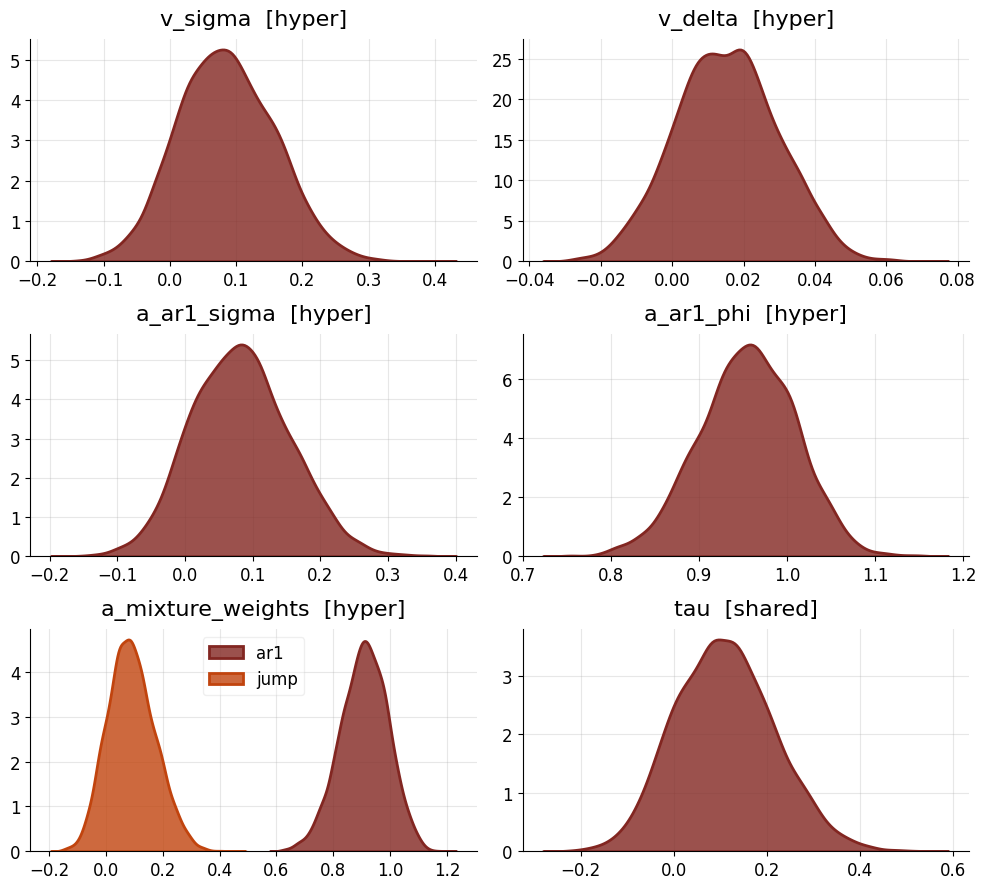

In [41]:
fig = workflow.plot_time_invariant_posterior(samples)